In [ ]:
import os
import sys
from pathlib import Path

# FOR LOCAL USE THIS LINES
current = Path.cwd()
src_path = current / "src" if (current / "src").exists() else current.parent

FOR COLAB USE THIS LINE INSTEAD
BRANCH_NAME = "semantic_geocell"  # Change this to switch branches
!git clone -b {BRANCH_NAME} https://github.com/MatteoCamillo-code/GeoLoc-CVCS.git
!cd /content/GeoLoc-CVCS && git pull origin {BRANCH_NAME} && cd ..
src_path = Path("/content/GeoLoc-CVCS/src").resolve()

sys.path.insert(0, str(src_path))

from utils.paths import find_project_root

# Set working directory and sys.path properly
project_root = find_project_root(src_path)
data_dir = project_root / "data"
history_dir = project_root / "outputs" / "history"
os.chdir(project_root)
sys.path.insert(0, str(project_root / "src"))
print("CWD:", Path.cwd())

## Libraries

In [1]:
import os
import pandas as pd
from PIL import Image
import torch
from torch.utils.data import Dataset, DataLoader
import numpy as np
from torchvision import transforms
import geopandas as gpd
import matplotlib.pyplot as plt
import torch.nn as nn
import torchvision.models as models
import torch.nn.functional as F
import torch.optim as optim
import torchvision
import torchvision.transforms.v2 as T
from torch.amp import GradScaler
from tqdm import tqdm
import time

## Setup

In [2]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


Loading the OSVmini dataset from Kaggle

In [3]:
#!pip install kagglehub
import kagglehub

path = kagglehub.dataset_download("josht000/osv-mini-129k")
path = path+'/osv5m'

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'osv-mini-129k' dataset.
Path to dataset files: /kaggle/input/osv-mini-129k/osv5m


Extracting Training/Validation Set Metadata and cell centroids

In [4]:
train_val_meta = pd.read_csv("/content/drive/MyDrive/osv5m/datasets/train_val_split_geocells.csv")
train_val_meta.head()

/tmp/ipython-input-3228591898.py:1: DtypeWarning: Columns (33) have mixed types. Specify dtype option on import or set low_memory=False.
  train_val_meta = pd.read_csv("/content/drive/MyDrive/osv5m/datasets/train_val_split_geocells.csv")


,id,latitude,longitude,thumb_original_url,country,sequence,captured_at,lon_bin,lat_bin,cell,...,unique_city,unique_country,creator_username,creator_id,predicted_label,s2_cell,is_train,label_config_1,label_config_2,label_config_3
0,175846147796767,31.807977,-109.051129,https://scontent-cdg4-3.xx.fbcdn.net/m1/v/t6/A...,US,ufvI_dqzSv-GNnWH7SrduA,1460743210350,18.0,64.0,"(18, 64)",...,Lordsburg_Hidalgo County_New Mexico_US,US,adotgis,1.005834e+14,Natural,CellId: 86d991cde1b03a05,1,86d99,86d99,86d9
1,327253605472404,31.805039,-109.053170,https://scontent-cdg4-1.xx.fbcdn.net/m1/v/t6/A...,US,ufvI_dqzSv-GNnWH7SrduA,1460743197630,18.0,64.0,"(18, 64)",...,Lordsburg_Hidalgo County_New Mexico_US,US,adotgis,1.005834e+14,Natural,CellId: 86d991d1b8c7fbd3,1,86d99,86d99,86d9
2,815733012693812,31.839720,-109.029062,https://scontent-cdg4-3.xx.fbcdn.net/m1/v/t6/A...,US,crag9qhk6sw89qnqvs1v0p,1460300841441,18.0,64.0,"(18, 64)",...,Lordsburg_Hidalgo County_New Mexico_US,US,drkludge,1.106021e+14,Natural,CellId: 86d990591818b4a1,1,86d99,86d99,86d9
3,471207127297520,31.812350,-109.048174,https://scontent-cdg4-1.xx.fbcdn.net/m1/v/t6/A...,US,8TlCI49QRTixfJhGqyDSNQ,1460743448990,18.0,64.0,"(18, 64)",...,Lordsburg_Hidalgo County_New Mexico_US,US,adotgis,1.005834e+14,Natural,CellId: 86d991cc873be437,1,86d99,86d99,86d9
4,1482670018574640,31.834722,-109.032378,https://scontent-cdg4-1.xx.fbcdn.net/m1/v/t6/A...,US,crag9qhk6sw89qnqvs1v0p,1460300880086,18.0,64.0,"(18, 64)",...,Lordsburg_Hidalgo County_New Mexico_US,US,drkludge,1.106021e+14,Natural,CellId: 86d9905a63f65097,1,86d99,86d99,86d9


In [5]:
cell_centers_df = pd.read_csv("/content/drive/MyDrive/osv5m/datasets/cell_center_dataset.csv")
cell_centers_df.head()

,cell_id_token,center_latitude,center_longitude,count,config_name
0,86d84,32.648380,-109.188005,5,config_1
1,86d904,32.286026,-108.712579,42,config_1
2,86d914,32.139738,-108.522571,1,config_1
3,86d91c,32.314937,-108.522571,8,config_1
4,86d99,31.804084,-108.997769,6,config_1


## Data Exploration and Visualization

Obtaining the US countries' borders for plotting

In [6]:
# Country borders
countries_url = (
    "https://naturalearth.s3.amazonaws.com/110m_cultural/"
    "ne_110m_admin_0_countries.zip"
)

# State / province borders
states_url = (
    "https://naturalearth.s3.amazonaws.com/110m_cultural/"
    "ne_110m_admin_1_states_provinces.zip"
)

world = gpd.read_file(countries_url)
states = gpd.read_file(states_url)

usa = world[world["NAME"] == "United States of America"]
usa_states = states[states["admin"] == "United States of America"]


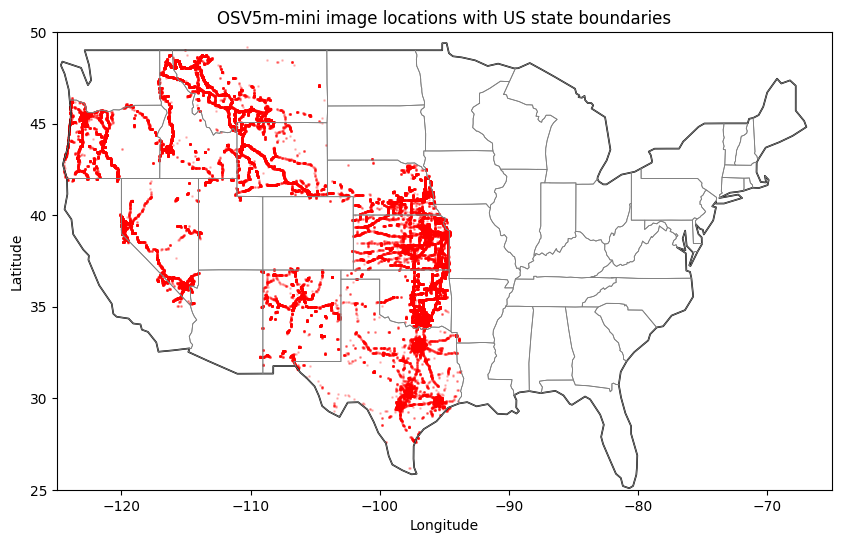

In [7]:
fig, ax = plt.subplots(figsize=(10, 6))

# US country outline
usa.boundary.plot(ax=ax, linewidth=1.2, color="black")

# State boundaries
usa_states.boundary.plot(ax=ax, linewidth=0.6, color="gray")

# Overlay image locations
ax.scatter(
    train_val_meta["longitude"],
    train_val_meta["latitude"],
    s=1,
    alpha=0.2,
    color="red"
)



# Continental US bounds
ax.set_xlim(-125, -65)
ax.set_ylim(25, 50)

ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_title("OSV5m-mini image locations with US state boundaries")

plt.show()


## New Geocell from embeddings clustering

In [16]:
train_meta = train_val_meta[train_val_meta['is_train'] == 1]
val_meta = train_val_meta[train_val_meta['is_train'] == 0]

In [17]:
gps_data = train_meta[['latitude', 'longitude']].values
gps_tensor = torch.tensor(gps_data, dtype=torch.float32)

print(f"Shape of GPS tensor: {gps_tensor.shape}")
print(f"Expected number of images: {len(train_meta)}")

# Verify that the number of rows matches the total number of images
assert gps_tensor.shape[0] == len(train_meta), "Number of GPS entries does not match total images in train_dataset!"
assert gps_tensor.shape[1] == 2, "GPS tensor should have 2 columns for latitude and longitude!"

Shape of GPS tensor: torch.Size([101156, 2])
Expected number of images: 101156


In [18]:
min_lat = gps_tensor[:, 0].min()
max_lat = gps_tensor[:, 0].max()
min_lon = gps_tensor[:, 1].min()
max_lon = gps_tensor[:, 1].max()

print(f"Original Latitude Range: [{min_lat:.4f}, {max_lat:.4f}]")
print(f"Original Longitude Range: [{min_lon:.4f}, {max_lon:.4f}]")

# Apply Min-Max scaling
# Formula: (value - min_value) / (max_value - min_value)
normalized_lat = (gps_tensor[:, 0] - min_lat) / (max_lat - min_lat)*5
normalized_lon = (gps_tensor[:, 1] - min_lon) / (max_lon - min_lon)*5

# Combine normalized latitude and longitude into a new tensor
normalized_gps_tensor = torch.stack((normalized_lat, normalized_lon), dim=1)

print(f"Shape of normalized_gps_tensor: {normalized_gps_tensor.shape}")

# Verify the range of normalized coordinates (should be between 0 and 1)
print(f"Normalized Latitude Range: [{normalized_gps_tensor[:, 0].min():.4f}, {normalized_gps_tensor[:, 0].max():.4f}]")
print(f"Normalized Longitude Range: [{normalized_gps_tensor[:, 1].min():.4f}, {normalized_gps_tensor[:, 1].max():.4f}]")

Original Latitude Range: [26.1652, 49.1955]
Original Longitude Range: [-124.5009, -93.7186]
Shape of normalized_gps_tensor: torch.Size([101156, 2])
Normalized Latitude Range: [0.0000, 5.0000]
Normalized Longitude Range: [0.0000, 5.0000]


In [19]:
visual_embeddings = torch.load("/content/drive/MyDrive/osv5m/datasets/osv5m_train_visual_embeddings.pt")

In [20]:
visual_embeddings = visual_embeddings[train_val_meta['is_train']==1]

In [21]:
visual_embeddings.shape

torch.Size([101156, 768])

In [22]:
import torch
import numpy as np
from sklearn.cluster import MiniBatchKMeans
from sklearn.decomposition import PCA
from sklearn.metrics.pairwise import haversine_distances


In [23]:
emb = visual_embeddings.cpu().numpy()
gps = gps_tensor.cpu().numpy()

In [24]:
R = 6371000  # Earth radius in meters

lat = np.deg2rad(gps[:, 0])
lon = np.deg2rad(gps[:, 1])

x = R * lon * np.cos(lat.mean())
y = R * lat

coords_m = np.stack([x, y], axis=1)  # [N, 2]

In [25]:
K_geo = 2000  # adjust depending on dataset coverage

In [26]:
geo_kmeans = MiniBatchKMeans(
    n_clusters=K_geo,
    batch_size=4096,
    random_state=42
)

geo_labels = geo_kmeans.fit_predict(coords_m)


In [27]:
MAX_DIAMETER_KM = 200
valid_geo_clusters = []

for g in range(K_geo):
    idx = np.where(geo_labels == g)[0]
    if len(idx) < 10:
        continue

    latlon = np.deg2rad(gps[idx])
    dists = haversine_distances(latlon)
    diameter_km = dists.max() * 6371

    if diameter_km <= MAX_DIAMETER_KM:
        valid_geo_clusters.append(g)


In [28]:
pca = PCA(n_components=128, random_state=42)
emb_reduced = pca.fit_transform(emb)

In [29]:
MIN_SEM_CLUSTER_SIZE = 50
MAX_SEM_CLUSTERS = 4

final_labels = -np.ones(len(emb), dtype=int)
label_counter = 0

for g in valid_geo_clusters:
    idx = np.where(geo_labels == g)[0]

    # Too small → keep as single geocell
    if len(idx) < MIN_SEM_CLUSTER_SIZE:
        final_labels[idx] = label_counter
        label_counter += 1
        continue

    k_sem = min(MAX_SEM_CLUSTERS, len(idx) // MIN_SEM_CLUSTER_SIZE)
    k_sem = max(k_sem, 1)

    sem_kmeans = MiniBatchKMeans(
        n_clusters=k_sem,
        batch_size=512,
        random_state=42
    )

    sem_labels = sem_kmeans.fit_predict(emb_reduced[idx])

    for s in range(k_sem):
        s_idx = idx[sem_labels == s]
        final_labels[s_idx] = label_counter
        label_counter += 1


In [30]:
final_labels.shape  # [119008]
num_geocells = final_labels.max() + 1

In [31]:
geocell_centers = []

for c in range(num_geocells):
    idx = np.where(final_labels == c)[0]
    geocell_centers.append(gps[idx].mean(axis=0))

geocell_centers = np.stack(geocell_centers)

In [32]:
!pip install geopandas shapely pyproj

In [33]:
import geopandas as gpd

# Country borders
countries_url = (
    "https://naturalearth.s3.amazonaws.com/110m_cultural/"
    "ne_110m_admin_0_countries.zip"
)

# State / province borders
states_url = (
    "https://naturalearth.s3.amazonaws.com/110m_cultural/"
    "ne_110m_admin_1_states_provinces.zip"
)

world = gpd.read_file(countries_url)
states = gpd.read_file(states_url)

usa = world[world["NAME"] == "United States of America"]
usa_states = states[states["admin"] == "United States of America"]


In [34]:
usa_states_contiguous = usa_states[usa_states["name"] != "Alaska"]


In [35]:
usa_states_contiguous = usa_states[
    ~usa_states["name"].isin(["Alaska", "Hawaii"])
]


In [36]:
usa_contiguous = usa_states_contiguous.dissolve(by="admin")

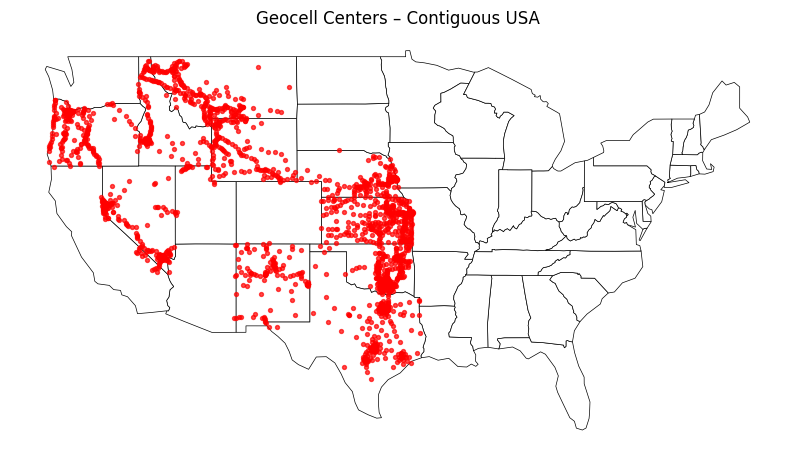

In [37]:
from shapely.geometry import Point
import matplotlib.pyplot as plt

gdf_cells = gpd.GeoDataFrame(
    geometry=[Point(lon, lat) for lat, lon in geocell_centers],
    crs="EPSG:4326"
)

fig, ax = plt.subplots(figsize=(10, 6))

usa_states_contiguous.plot(
    ax=ax,
    color="white",
    edgecolor="black",
    linewidth=0.5
)

gdf_cells.plot(
    ax=ax,
    markersize=8,
    color="red",
    alpha=0.7
)

ax.set_title("Geocell Centers – Contiguous USA")
ax.set_axis_off()
plt.show()


In [38]:
import numpy as np

geo_centers = []

for g in np.unique(geo_labels):
    idx = np.where(geo_labels == g)[0]
    geo_centers.append(gps[idx].mean(axis=0))

geo_centers = np.array(geo_centers)  # [K_geo, 2]


In [39]:
import geopandas as gpd
from shapely.geometry import Point

gdf_centers = gpd.GeoDataFrame(
    geometry=[Point(lon, lat) for lat, lon in geo_centers],
    crs="EPSG:4326"
)


In [40]:
gdf_centers_m = gdf_centers.to_crs("EPSG:5070")
usa_m = usa_states_contiguous.to_crs("EPSG:5070")


In [41]:
from shapely.ops import voronoi_diagram
from shapely.geometry import MultiPoint

points = MultiPoint(gdf_centers_m.geometry.values)

vor = voronoi_diagram(
    points,
    envelope=usa_m.union_all(),  # limits extent
    edges=False
)


In [42]:
vor_gdf = gpd.GeoDataFrame(
    geometry=list(vor.geoms),
    crs=usa_m.crs
)


In [43]:
vor_usa = gpd.clip(vor_gdf, usa_m)


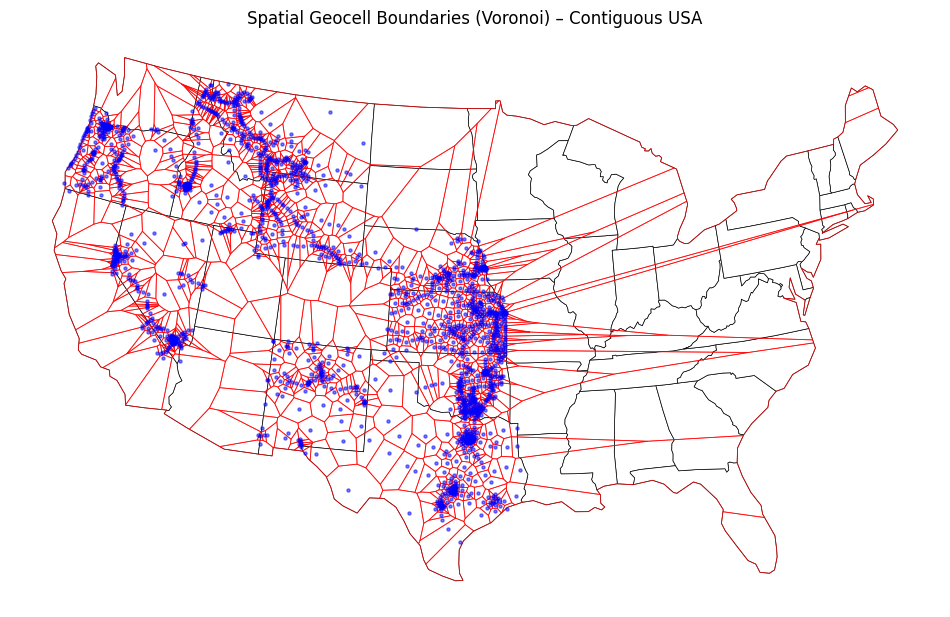

In [44]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(12, 8))

usa_states_contiguous.to_crs("EPSG:5070").plot(
    ax=ax,
    color="white",
    edgecolor="black",
    linewidth=0.5
)

vor_usa.plot(
    ax=ax,
    facecolor="none",
    edgecolor="red",
    linewidth=0.6,
    alpha=0.8
)

gdf_centers_m.plot(
    ax=ax,
    color="blue",
    alpha = 0.5,
    markersize=5
)

ax.set_title("Spatial Geocell Boundaries (Voronoi) – Contiguous USA")
ax.set_axis_off()
plt.show()


In [45]:
import numpy as np

R = 6371000  # meters

def project_latlon(latlon):
    lat = np.deg2rad(latlon[:, 0])
    lon = np.deg2rad(latlon[:, 1])
    x = R * lon * np.cos(lat.mean())
    y = R * lat
    return np.stack([x, y], axis=1)


In [46]:
gps_val = val_meta[['latitude', 'longitude']].values
# gps_tensor = torch.tensor(gps_data, dtype=torch.float32)
# gps = gps_tensor.cpu().numpy()

In [47]:
geo_centers_m = project_latlon(geo_centers)   # [K_geo, 2]
gps_val_m = project_latlon(gps_val)           # [N_val, 2]

In [48]:
from sklearn.neighbors import KDTree

tree = KDTree(geo_centers_m)
_, val_geo_labels = tree.query(gps_val_m, k=1)

val_geo_labels = val_geo_labels.squeeze()  # [N_val]

In [54]:
final_geo_labels = []
train = -1
val = -1

for split in train_val_meta['is_train']:
  if split == 1:
    train += 1
    final_geo_labels.append(geo_labels[train])
  else:
    val += 1
    final_geo_labels.append(val_geo_labels[val])

In [55]:
len(final_geo_labels)

119008

In [57]:
train_val_meta['label_config_1'] = final_geo_labels

In [58]:
output_csv_path = "/content/drive/MyDrive/osv5m/datasets/train_val_split_geoclusters.csv"
train_val_meta.to_csv(output_csv_path, index=False)
print(f"Updated train_val_meta saved to: {output_csv_path}")

Updated train_val_meta saved to: /content/drive/MyDrive/osv5m/datasets/train_val_split_geoclusters.csv


In [62]:
import pandas as pd
import numpy as np

geo_centers_np = np.asarray(geo_centers)

df = pd.DataFrame({
    "label": np.arange(len(geo_centers_np), dtype=int),
    "center_latitude": geo_centers_np[:, 0],
    "center_longitude": geo_centers_np[:, 1],
    "config_name": "config_1",
})


In [63]:
output_csv_path = "/content/drive/MyDrive/osv5m/datasets/cell_center_dataset_geoclusters.csv"
df.to_csv(output_csv_path, index=False)